In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI

# 모델 초기화
model = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite")
model.invoke("안녕하세요!")

AIMessage(content=[{'type': 'text', 'text': '안녕하세요! 반갑습니다. 무엇을 도와드릴까요?', 'extras': {'signature': 'EjQKMgERTTIPKwIqaobqWV7HRNC/FOmYVIpYbPlNNXdfO+E3rTtZEowqACK8KpABsnMoa5+q'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019fe408-49b4-7590-8078-cd647ac38252-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 3, 'output_tokens': 10, 'total_tokens': 13, 'input_token_details': {'cache_read': 0}})

In [2]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


class State(TypedDict):
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
      messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.
      'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.
      (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다.)
    """

    messages: Annotated[list[str], add_messages]


# StateGraph 클래스를 사용하여 State 타입의 그래프 생성
graph_builder = StateGraph(State)

In [3]:
def generate(state: State):
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.

    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리.
      형식은 {"messages":[응답 메시지]}  입니다.
    """
    return {"messages": [model.invoke(state["messages"])]}


graph_builder.add_node("generate", generate)

graph 선언하기


In [ ]:
graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)

graph = graph_builder.compile()

그래프 도식화하기


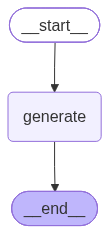

In [5]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    pass

리스트에 문장 추가하기


In [6]:
response = graph.invoke({"messages": ["안녕하세요! 저는 남열입니다."]})

print(type(response))
response

<class 'dict'>


{'messages': [HumanMessage(content='안녕하세요! 저는 남열입니다.', additional_kwargs={}, response_metadata={}, id='1f79adcb-f95c-497a-98db-4268a9ab3751'),
  AIMessage(content=[{'type': 'text', 'text': '안녕하세요, 남열 님! 만나서 정말 반갑습니다. 오늘 하루는 어떻게 보내고 계신가요? 제가 도와드릴 일이 있다면 무엇이든 편하게 말씀해 주세요!', 'extras': {'signature': 'EjQKMgERTTIPl/Rj93w9CXfE5jjNzp0vg7GKSdgcTWVU4WE4kckh23oeC3EPHDu/DOc/KAcG'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019fe414-0cb6-7720-9899-bc5dc836b86a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 37, 'total_tokens': 45, 'input_token_details': {'cache_read': 0}})]}

이전 대화 내용 새 메시지 추가하기

In [7]:
response["messages"].append("제 이름을 아시나요?")
graph.invoke(response)

{'messages': [HumanMessage(content='안녕하세요! 저는 남열입니다.', additional_kwargs={}, response_metadata={}, id='1f79adcb-f95c-497a-98db-4268a9ab3751'),
  AIMessage(content=[{'type': 'text', 'text': '안녕하세요, 남열 님! 만나서 정말 반갑습니다. 오늘 하루는 어떻게 보내고 계신가요? 제가 도와드릴 일이 있다면 무엇이든 편하게 말씀해 주세요!', 'extras': {'signature': 'EjQKMgERTTIPl/Rj93w9CXfE5jjNzp0vg7GKSdgcTWVU4WE4kckh23oeC3EPHDu/DOc/KAcG'}}], additional_kwargs={}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--019fe414-0cb6-7720-9899-bc5dc836b86a-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 37, 'total_tokens': 45, 'input_token_details': {'cache_read': 0}}),
  HumanMessage(content='제 이름을 아시나요?', additional_kwargs={}, response_metadata={}, id='28291d62-3fc7-43c0-8543-e888c7a89415'),
  AIMessage(content=[{'type': 'text', 'text': '네, 방금 말씀해 주셨잖아요! **남열** 님이라고 하셨죠. 기억하고 있습니다. :)', 'extras': {'signature': 'EjQ

스트림 방식으로 출력하기

In [11]:
inputs = {"messages": [("human", "한국과 일본의 관계에 대해 자세히 알려줘.")]}
for chunk, _ in graph.stream(inputs, stream_mode="messages"):
    print(chunk.content, end="")

[{'type': 'text', 'text': '한국과 일본의 관계는 **‘가깝고도 먼', 'index': 0}][{'type': 'text', 'text': ' 나라’**라는 말로 요약될 만큼 복잡하고 다층적입니다. 지리적·문화적으로는 매우', 'index': 0}][{'type': 'text', 'text': ' 밀접하지만, 역사적 갈등과 정치적 이해관계로 인해 긴장과 화해가 반복되어 왔습니다', 'index': 0}][{'type': 'text', 'text': '.\n\n주요 내용을 4가지 핵심 포인트로 나누어 정리해 드립니다.\n\n---\n\n### 1. 역사적', 'index': 0}][{'type': 'text', 'text': ' 배경과 갈등 (가장 큰 걸림돌)\n한일 관계에서 가장 큰 비중을 차지하는 것은 **', 'index': 0}][{'type': 'text', 'text': '일제강점기(1910~1945)**의 역사입니다. 이 시기의 상처가 현대 정치', 'index': 0}][{'type': 'text', 'text': '에도 큰 영향을 미치고 있습니다.\n\n*   **식민지 지배의 성격:** 한국은 일', 'index': 0}][{'type': 'text', 'text': '제강점기를 강제 점령과 수탈로 보지만, 일본 내 우익 세력은 이를 근', 'index': 0}][{'type': 'text', 'text': '대화의 과정으로 미화하려는 경향이 있어 갈등이 발생합니다.\n*   **핵', 'index': 0}][{'type': 'text', 'text': '심 쟁점:** \n    *   **강제징용 문제:** 일제강점기 강제 동원된 피해자', 'index': 0}][{'type': 'text', 'text': '들에 대한 배상 문제(한국 대법원의 배상 판결 vs 일본의 "1965년 한', 'index': 0}][{'type': 'text', 'text': '일청구권협정으로 해결되었다"는 입장).\n    *   **위안부 문